# Классификация изображений

## Вступление
Сегодня мы перейдём чуть более сложным данным и архитектурам для классификации изображений.

### План семинара
1. Обучаем свёрточную сеть для задачи классификации изображений и смотрим на полученные фильтры свёрточных слоёв
2. Разбираемся с тем, что такое аугментации и зачем они нужны
3. Применим способы регуляризации и нормализации при обучении нейронных сетей


In [5]:
from torchvision import models

mobilenet = models.mobilenet_v3_small(weights=models.MobileNet_V3_Small_Weights.DEFAULT)
mobilenet.classifier[3]

Linear(in_features=1024, out_features=1000, bias=True)

In [ ]:
import warnings

import matplotlib.pyplot as plt
import numpy as np
import torch
import torchvision
from IPython.display import clear_output
from torch import nn, optim
from torchvision import transforms
from tqdm.auto import tqdm

warnings.filterwarnings("ignore")
%matplotlib inline

In [ ]:
device = "cuda" if torch.cuda.is_available() else "cpu"
device

'cuda'

## 1. Обучаем свёрточную сеть для задачи классификации изображений

### Давайте познакомимся с датасетом CIFAR-10

**CIFAR-10** (Canadian Institute For Advanced Research) - это популярный датасет для задач компьютерного зрения, содержащий 60 000 цветных изображений размером 32×32 пикселя, разделенных на 10 классов:

- Самолёт (airplane)
- Автомобиль (automobile)
- Птица (bird)
- Кот (cat)
- Олень (deer)
- Собака (dog)
- Лягушка (frog)
- Лошадь (horse)
- Корабль (ship)
- Грузовик (truck)

**Структура датасета:**
- Обучающая выборка: 50 000 изображений
- Тестовая выборка: 10 000 изображений

**Особенности датасета:**
- Маленький размер изображений (32×32) позволяет быстро экспериментировать
- Разнообразные классы объектов
- Реальные фотографии с различными условиями освещения и ракурсами

Загрузим датасет аналогично тому, как мы загружали MNIST на предыдущих занятиях, но с учетом особенностей цветных изображений.

In [ ]:
transform = transforms.Compose(
    [
        transforms.ToTensor(),
        transforms.Normalize((0.4914, 0.4822, 0.4465), (0.247, 0.243, 0.261)),
    ]
)

cifar_train = torchvision.datasets.CIFAR10(
    root="./cifar", train=True, download=True, transform=transform
)
cifar_val = torchvision.datasets.CIFAR10(
    root="./cifar", train=False, download=True, transform=transform
)

train_dataloader = torch.utils.data.DataLoader(
    cifar_train, batch_size=32, shuffle=True, num_workers=4
)
val_dataloader = torch.utils.data.DataLoader(
    cifar_val, batch_size=32, shuffle=False, num_workers=4
)

100%|██████████| 170M/170M [00:02<00:00, 77.6MB/s]


In [ ]:
def matplotlib_imshow(img, one_channel=False):
    if one_channel:
        img = img.mean(dim=0)
    img = img / 2 + 0.5
    npimg = img.numpy()
    if one_channel:
        plt.imshow(npimg, cmap="Greys")
    else:
        plt.imshow(np.transpose(npimg, (1, 2, 0)))

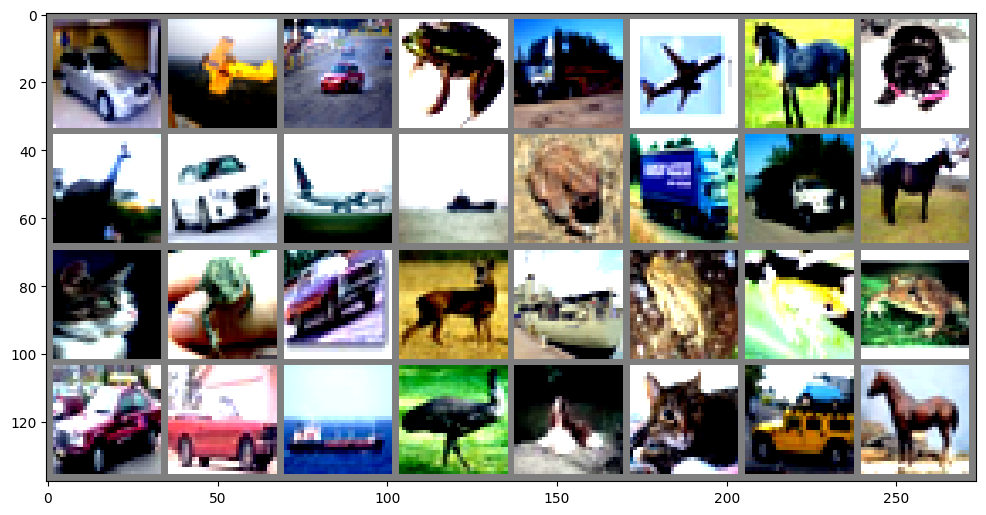

In [ ]:
images, labels = next(iter(train_dataloader))

plt.figure(figsize=(12, 12))
# create grid of images
img_grid = torchvision.utils.make_grid(images)
# show images
matplotlib_imshow(img_grid, one_channel=False)

In [ ]:
def plot_history(train_history, val_history, title="loss"):
    plt.figure()
    plt.title(title)
    plt.plot(train_history, label="train", zorder=1)

    points = np.array(val_history)
    steps = list(
        range(0, len(train_history) + 1, int(len(train_history) / len(val_history)))
    )[1:]

    plt.scatter(
        steps, val_history, marker="+", s=180, c="orange", label="val", zorder=2
    )
    plt.xlabel("train steps")

    plt.legend(loc="best")
    plt.grid()

    plt.show()

### VGG
Построим следующую архитектуру из 1 VGG блока:

1) VGG блок с 16 каналами:
* свёрточный слой с 16 выходными каналами и ядром 3x3, паддингом и нелинейностью ReLU
* свёрточный слой с 16 выходными каналами и ядром 3x3, паддингом и нелинейностью ReLU
* Max pooling c ядром 2x2 и шагом 2

2) Полносвязный слой с 128 выходами и нелинейностью ReLU

3) Полносвязный слой с 10 выходами

In [ ]:
net = nn.Sequential(
    nn.Conv2d(3, 16, 3, padding=1),
    nn.ReLU(),
    nn.Conv2d(16, 16, 3, padding=1),
    nn.ReLU(),
    nn.MaxPool2d(2),
)
net(torch.rand((1, 3, 32, 32))).size()

torch.Size([1, 16, 16, 16])

In [ ]:
class ModelBaseline(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(3, 16, 3, padding=1),
            nn.ReLU(),
            nn.Conv2d(16, 16, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Flatten(),  # .reshape(batch, -1)
            nn.LazyLinear(128),
            nn.ReLU(),
            nn.Linear(128, 10),
        )

    def forward(self, x):
        if len(x.size()) < 4:
            return self.net(x.unsqueeze(0)).squeeze(0)
        return self.net(x)

In [ ]:
def train(model, criterion, optimizer, train_dataloader, val_dataloader, n_epochs=5):
    train_loss_log, train_acc_log, val_loss_log, val_acc_log = [], [], [], []

    for epoch in range(n_epochs):
        # тренировка
        train_epoch_loss, train_epoch_true_hits = torch.empty(0), torch.empty(0)
        model.train()
        for imgs, labels in tqdm(
            train_dataloader, desc=f"Training, epoch {epoch}", leave=False
        ):
            imgs, labels = imgs.to(device), labels.to(device)

            y_pred = model(imgs)
            loss = criterion(y_pred, labels)
            loss.backward()
            optimizer.step()
            optimizer.zero_grad()

            # log loss for the current epoch and the whole training history
            train_epoch_loss = torch.cat(
                (train_epoch_loss, loss.cpu().unsqueeze(0) / labels.cpu().size(0))
            )
            train_loss_log.append(loss.cpu().data / labels.cpu().size(0))

            # log accuracy for the current epoch and the whole training history
            pred_classes = torch.argmax(y_pred.cpu(), dim=-1)
            train_epoch_true_hits = torch.cat(
                (
                    train_epoch_true_hits,
                    (pred_classes == labels.cpu()).sum().unsqueeze(0),
                )
            )
            train_acc_log.append(
                (pred_classes == labels.cpu()).sum() / labels.cpu().shape[0]
            )

        # валидация
        val_epoch_loss, val_epoch_true_hits = torch.empty(0), torch.empty(0)
        model.eval()
        with torch.no_grad():
            for imgs, labels in tqdm(
                val_dataloader, desc=f"Validating, epoch {epoch}", leave=False
            ):
                imgs, labels = imgs.to(device), labels.to(device)

                y_pred = model(imgs)
                loss = criterion(y_pred, labels)
                val_epoch_loss = torch.cat(
                    (val_epoch_loss, loss.cpu().unsqueeze(0) / labels.cpu().size(0))
                )

                pred_classes = torch.argmax(y_pred.cpu(), dim=-1)
                val_epoch_true_hits = torch.cat(
                    (
                        val_epoch_true_hits,
                        (pred_classes == labels.cpu()).sum().unsqueeze(0),
                    )
                )

        val_loss_log.append(val_epoch_loss.mean())
        val_acc_log.append(
            val_epoch_true_hits.sum()
            / val_epoch_true_hits.size(0)
            / val_dataloader.batch_size
        )
        clear_output()
        plot_history(train_loss_log, val_loss_log, "loss")
        plot_history(train_acc_log, val_acc_log, "accuracy")

        print("Train loss:", train_epoch_loss.mean().item())
        print(
            "Train acc:",
            (
                train_epoch_true_hits.sum()
                / train_epoch_true_hits.size(0)
                / train_dataloader.batch_size
            ).item(),
        )
        print("Val loss:", val_epoch_loss.mean().item())
        print(
            "Val acc:",
            (
                val_epoch_true_hits.sum()
                / val_epoch_true_hits.size(0)
                / val_dataloader.batch_size
            ).item(),
        )

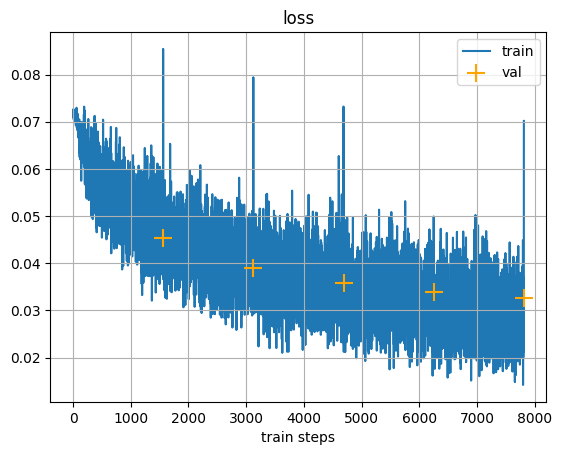

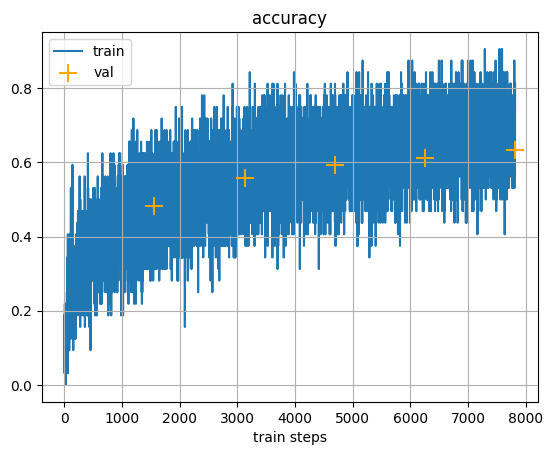

Train loss: 0.02931186370551586
Train acc: 0.6701855659484863
Val loss: 0.03272435814142227
Val acc: 0.634085476398468


In [ ]:
model_baseline = ModelBaseline().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(model_baseline.parameters(), lr=0.001, momentum=0.9)

train(model_baseline, criterion, optimizer, train_dataloader, val_dataloader)

### Посмотрим на работу фильтров

In [ ]:
# Запустите эти ячейки при работе из колаба
!wget https://raw.githubusercontent.com/hse-ds/iad-deep-learning/master/2022/seminars/sem03/filter_viz.py

import sys

from google.colab import drive

drive.mount("/content/gdrive")
sys.path.append("/content/gdrive/My Drive")

--2025-11-29 15:29:19--  https://raw.githubusercontent.com/hse-ds/iad-deep-learning/master/2022/seminars/sem03/filter_viz.py
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 3188 (3.1K) [text/plain]
Saving to: ‘filter_viz.py’

filter_viz.py       100%[===================>]   3.11K  --.-KB/s    in 0s      

2025-11-29 15:29:20 (34.8 MB/s) - ‘filter_viz.py’ saved [3188/3188]

Mounted at /content/gdrive


In [ ]:
from filter_viz import plot_filters

In [ ]:
model_baseline.cpu()

ModelBaseline(
  (net): Sequential(
    (0): Conv2d(3, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(16, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU()
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (5): Flatten(start_dim=1, end_dim=-1)
    (6): Linear(in_features=4096, out_features=128, bias=True)
    (7): ReLU()
    (8): Linear(in_features=128, out_features=10, bias=True)
  )
)

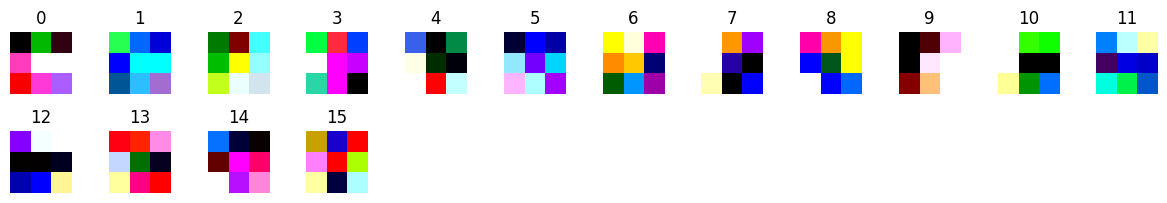

In [ ]:
plot_filters(model_baseline.net[0], single_channel=False)

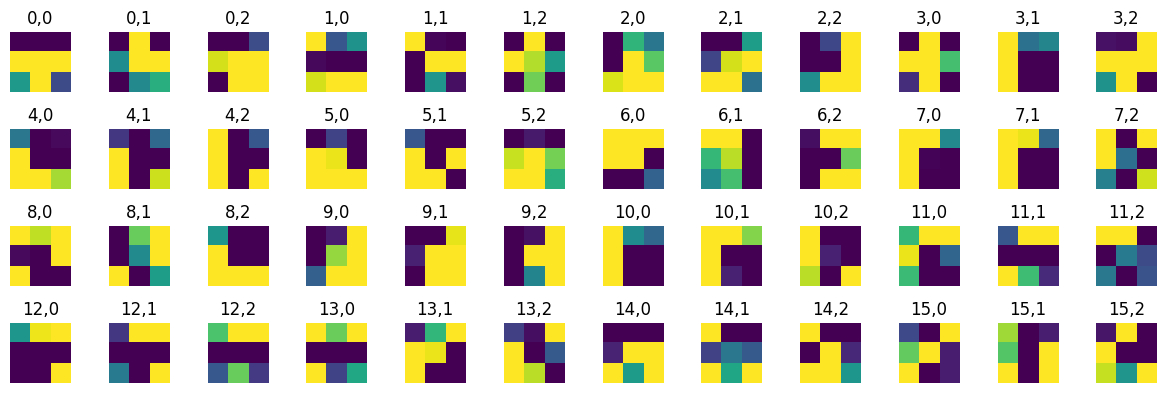

In [ ]:
plot_filters(model_baseline.net[0], single_channel=True)

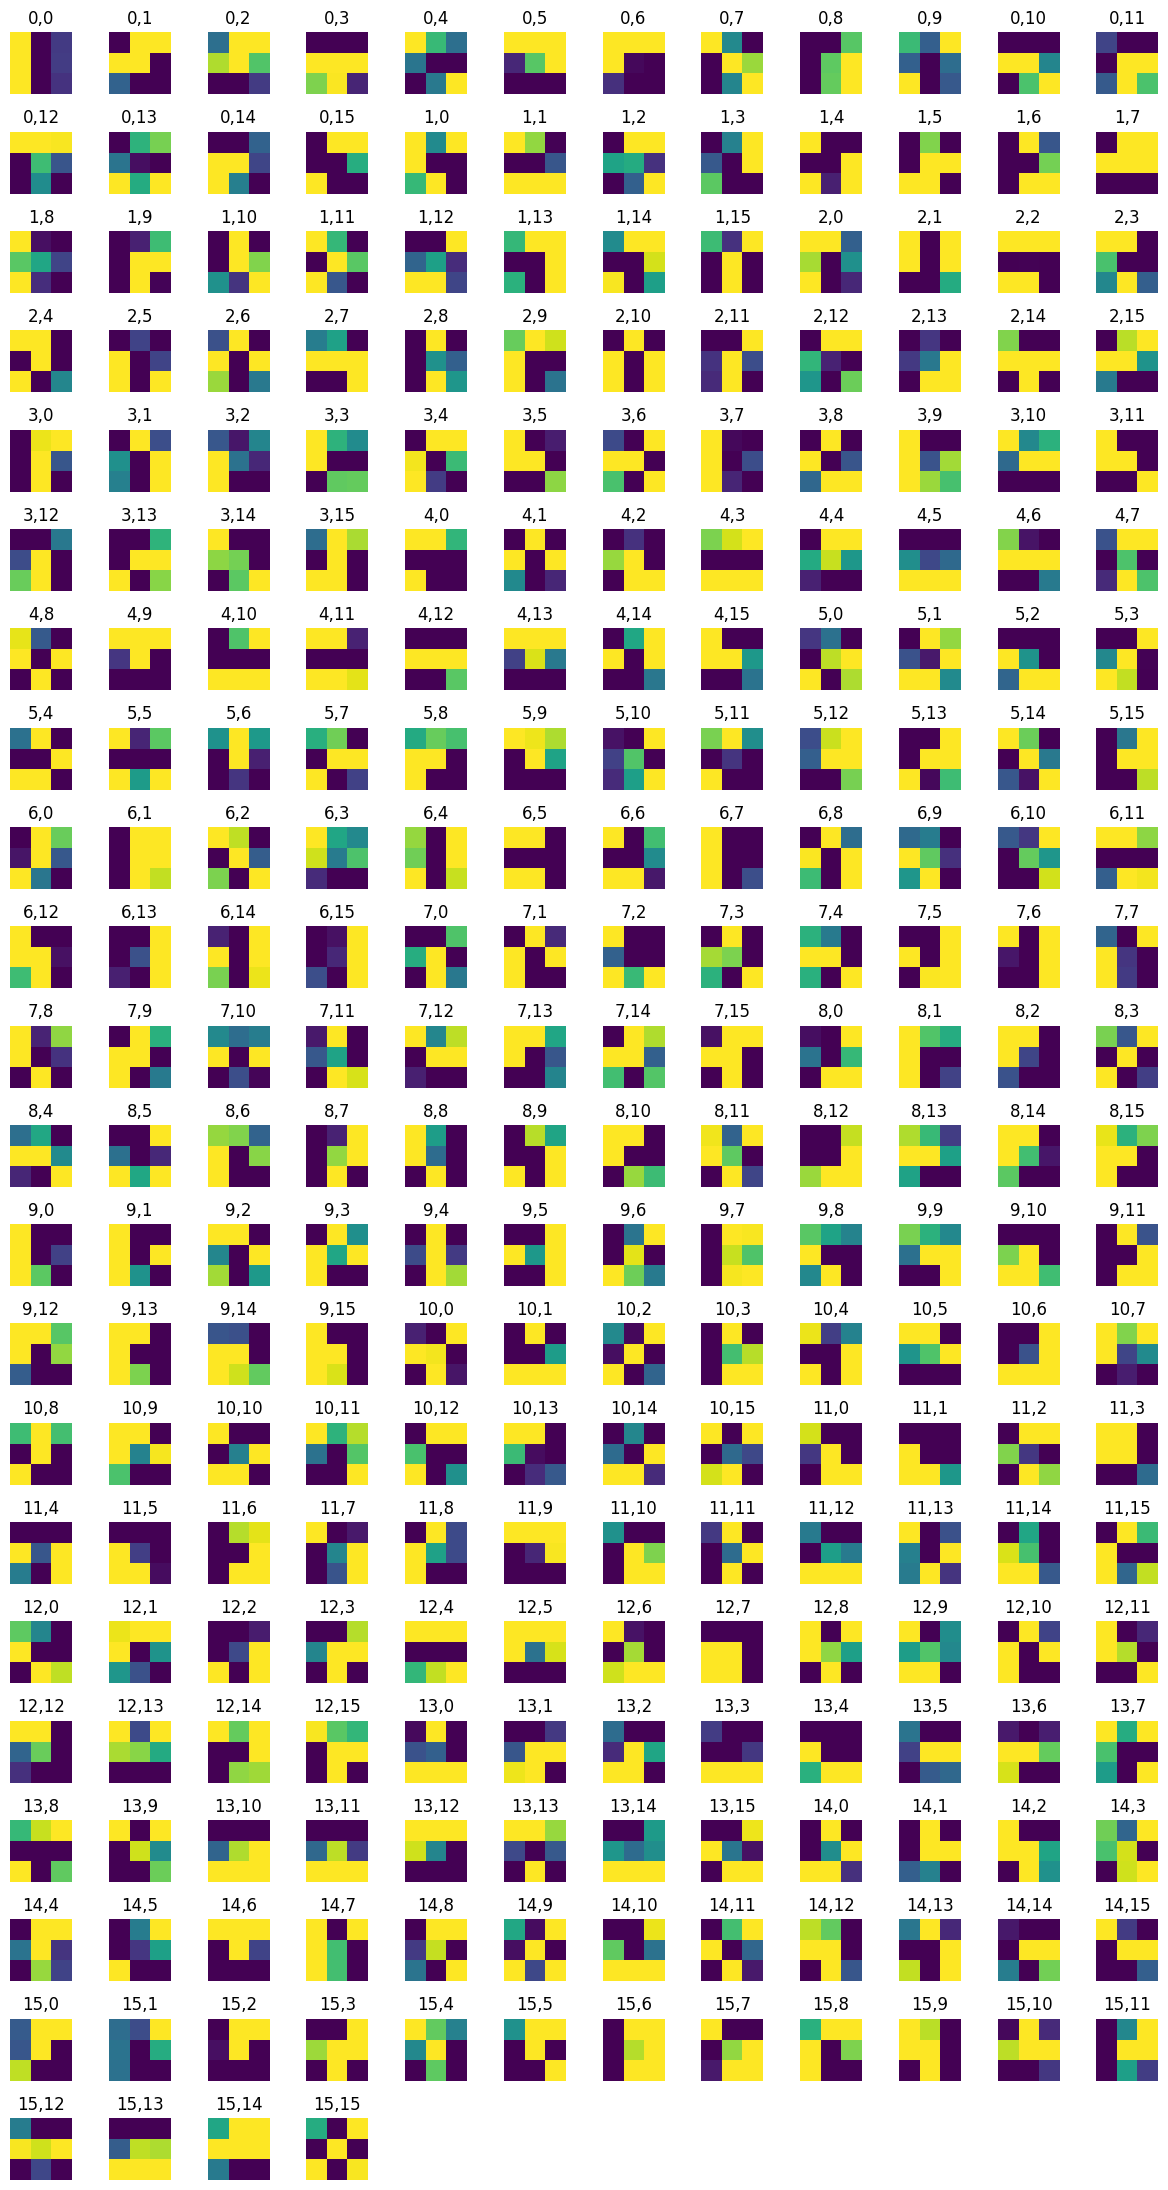

In [ ]:
plot_filters(model_baseline.net[2], single_channel=True)

### Работа различных функций активации

Попробуем поэкспериментировать с функциями активации нейронной сети. Попробуем заменить ReLU на LeakyReLU, ELU или SELU и попытаемся понять как замена влияет на качество и скорость сходимости?

Почитать про разные функции активации можно [здесь](https://ml-explained.com/blog/activation-functions-explained) и в [документации PyTorch](https://pytorch.org/docs/stable/nn.html#non-linear-activations-weighted-sum-nonlinearity).

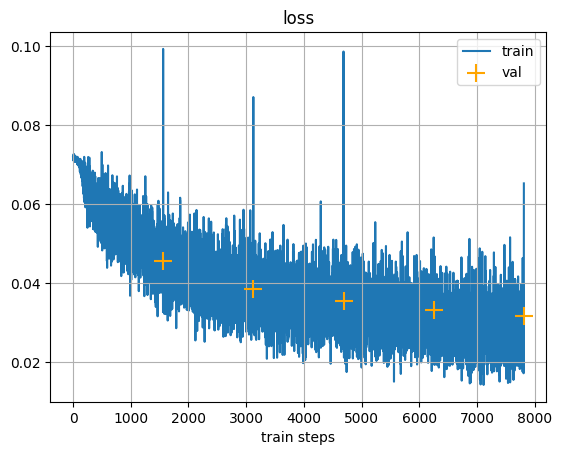

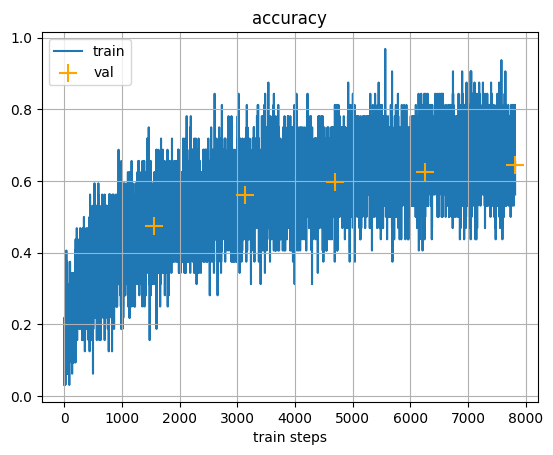

Train loss: 0.028841352090239525
Train acc: 0.676223635673523
Val loss: 0.03163111209869385
Val acc: 0.6438698172569275


In [ ]:
class ModelBaseline(nn.Module):
    def __init__(self, activation=nn.ReLU):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(3, 16, 3, padding=1),
            activation(),
            nn.Conv2d(16, 16, 3, padding=1),
            activation(),
            nn.MaxPool2d(2),
            nn.Flatten(),  # .reshape(batch, -1)
            nn.LazyLinear(128),
            activation(),
            nn.Linear(128, 10),
        )

    def forward(self, x):
        if len(x.size()) < 4:
            return self.net(x.unsqueeze(0)).squeeze(0)
        return self.net(x)


model_baseline2 = ModelBaseline(activation=nn.LeakyReLU).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(model_baseline2.parameters(), lr=0.001, momentum=0.9)

train(model_baseline2, criterion, optimizer, train_dataloader, val_dataloader)

C LeakyReLU работает немного лучше)

## 2. Аугментации

**Аугментация данных** - это техника искусственного увеличения размера обучающей выборки путем применения различных преобразований к исходным изображениям.

**Основные цели аугментаций:**
1. **Увеличение diversity** - модель видит больше вариаций данных
2. **Регуляризация** - предотвращение переобучения
3. **Повышение robustness** - модель становится устойчивее к различным искажениям

### Типы аугментаций:

**Геометрические преобразования:**
- Повороты и отражения
- Масштабирование и кроппинг
- Искажения перспективы

**Цветовые преобразования:**
- Изменение яркости, контрастности
- Коррекция гаммы
- Цветовые искажения

**Прочие преобразования:**
- Добавление шума
- Размытие
- Эластичные деформации

В PyTorch аугментации реализованы через модуль `torchvision.transforms`. С помощью функции Compose можно объединять несколько трансформаций изображения, а потом применять их при чтении датасета. Полный список аугментаций доступен [тут](https://pytorch.org/vision/stable/transforms.html). Изучите его и поэкспериментируйте с различными трансформациями изображения.

Довольно мощным и эффективным инструментом для аугментаций на картинках является библиотека `albumentations`.

In [ ]:
import PIL

transform = transforms.Compose(
    [
        transforms.ColorJitter(hue=0.05, saturation=0.05),
        transforms.RandomHorizontalFlip(),
        transforms.RandomRotation(20),
        transforms.ToTensor(),
        transforms.Normalize((0.4914, 0.4822, 0.4465), (0.247, 0.243, 0.261)),
    ]
)

base_transform = torchvision.transforms.Compose(
    [
        torchvision.transforms.ToTensor(),
        transforms.Normalize((0.4914, 0.4822, 0.4465), (0.247, 0.243, 0.261)),
    ]
)

cifar_train = torchvision.datasets.CIFAR10(
    root="./cifar", train=True, download=True, transform=transform
)
cifar_val = torchvision.datasets.CIFAR10(
    root="./cifar", train=False, download=True, transform=base_transform
)

train_dataloader = torch.utils.data.DataLoader(
    cifar_train, batch_size=32, shuffle=True, num_workers=4
)
val_dataloader = torch.utils.data.DataLoader(
    cifar_val, batch_size=32, shuffle=False, num_workers=4
)

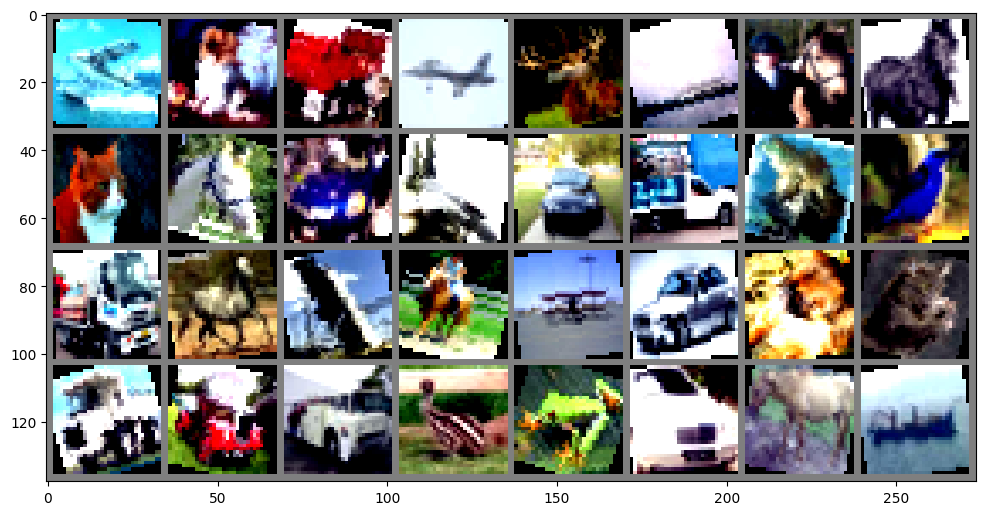

In [ ]:
images, labels = next(iter(train_dataloader))

plt.figure(figsize=(12, 12))
# create grid of images
img_grid = torchvision.utils.make_grid(images)
# show images
matplotlib_imshow(img_grid, one_channel=False)

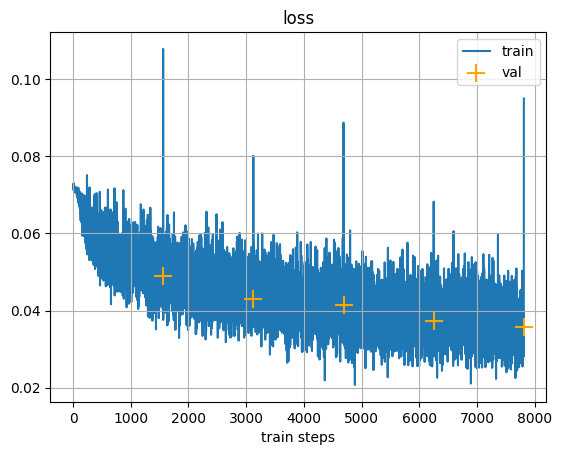

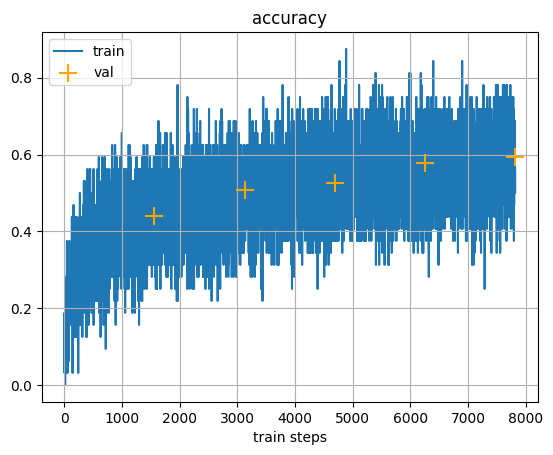

Train loss: 0.03744382783770561
Train acc: 0.5755957961082458
Val loss: 0.035720132291316986
Val acc: 0.5939496755599976


In [ ]:
model_baseline = ModelBaseline().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(model_baseline.parameters(), lr=0.001, momentum=0.9)

train(model_baseline, criterion, optimizer, train_dataloader, val_dataloader)

Давайте обучим новую сеть, в которой будет 3 VGG блока и добавим в неё батч нормализацию и дропаут.

In [ ]:
model = nn.Sequential(
    nn.Conv2d(3, 16, 3, padding=1),
    nn.BatchNorm2d(16),
    nn.ReLU(),
    nn.Conv2d(16, 16, 3, padding=1),
    nn.BatchNorm2d(16),
    nn.ReLU(),
    nn.MaxPool2d(2, 2),
    nn.Dropout(0.2),
    nn.Conv2d(16, 32, 3, padding=1),
    nn.BatchNorm2d(32),
    nn.ReLU(),
    nn.Conv2d(32, 32, 3, padding=1),
    nn.BatchNorm2d(32),
    nn.ReLU(),
    nn.MaxPool2d(2, 2),
    nn.Dropout(0.2),
    nn.Conv2d(32, 64, 3, padding=1),
    nn.BatchNorm2d(64),
    nn.ReLU(),
    nn.Conv2d(64, 64, 3, padding=1),
    nn.BatchNorm2d(64),
    nn.ReLU(),
    nn.MaxPool2d(2, 2),
    nn.Dropout(0.2),
    nn.Flatten(),
    nn.Linear(64 * 4 * 4, 128),
    nn.BatchNorm1d(128),
    nn.ReLU(),
    nn.Dropout(0.5),
    nn.Linear(128, 10),
)

In [ ]:
model.to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(model.parameters(), lr=0.001, momentum=0.9)

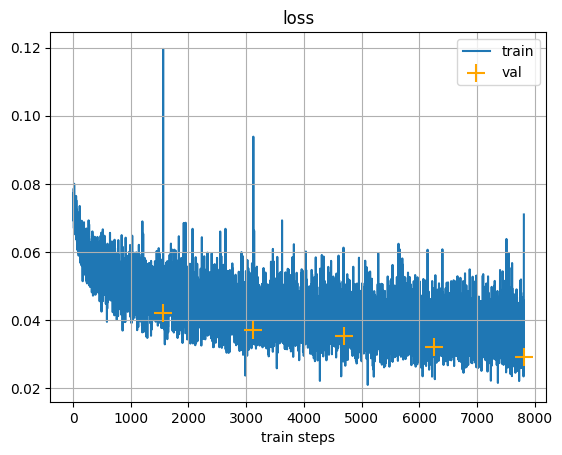

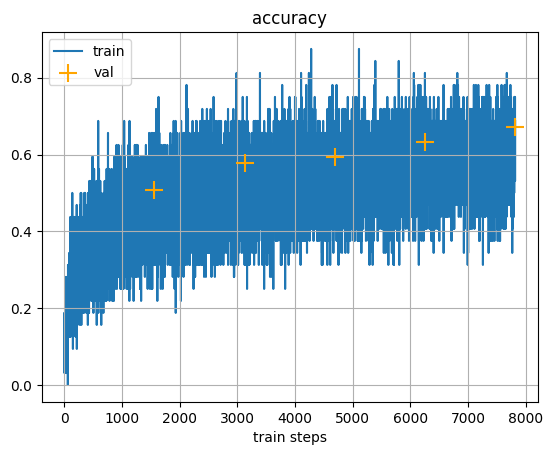

Train loss: 0.03735606372356415
Train acc: 0.5757357478141785
Val loss: 0.029073437675833702
Val acc: 0.6714257001876831


In [ ]:
train(model, criterion, optimizer, train_dataloader, val_dataloader)

## PyTorch VS PyTorch Lightning

[**PyTorch Lightning**](https://pytorch-lighting.readthedocs.io/en/stable/) это фреймворк, в котором упрощена работа по:
- написанию тренировочного цикла
- написанию датасетов
- использованию gpu/tpu/ipu/hpu и тд
- переводу моделей в формат ONNX
- и многому другому

Фреймворк предоставляют пользователю возможность конфигурировать параметры и проводить эксперименты, при этом не занимаясь "рутинными" и "техническими" деталями. Давайте сравним код на **PyTorch** без и с использованием **Lightning** на примере несложной нейросети на датасете FashionMNIST.

In [ ]:
!pip install lightning

from collections import defaultdict, namedtuple

import pytorch_lightning as pl
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader
from torchmetrics.functional import accuracy

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.9/44.9 kB 1.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 846.0/846.0 kB 17.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.2/983.2 kB 43.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 849.5/849.5 kB 44.6 MB/s eta 0:00:00


### Подготовка данных (общее для обоих подходов)

Определим DataLoader для тренировочных и валидационных выборок

In [ ]:
fashion_mnist_train = torchvision.datasets.FashionMNIST(
    "./data", download=True, transform=transforms.Compose([transforms.ToTensor()])
)
train_dataloader = DataLoader(
    fashion_mnist_train, batch_size=128, shuffle=True, num_workers=4
)

100%|██████████| 26.4M/26.4M [00:01<00:00, 19.0MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 307kB/s]
100%|██████████| 4.42M/4.42M [00:00<00:00, 5.62MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 21.9MB/s]


In [ ]:
fashion_mnist_val = torchvision.datasets.FashionMNIST(
    "./data",
    train=False,
    download=True,
    transform=transforms.Compose([transforms.ToTensor()]),
)
val_dataloader = DataLoader(fashion_mnist_val, batch_size=128, num_workers=4)

In [ ]:
idx_to_label = defaultdict(
    None,
    {
        0: "T-shirt/Top",
        1: "Trouser",
        2: "Pullover",
        3: "Dress",
        4: "Coat",
        5: "Sandal",
        6: "Shirt",
        7: "Sneaker",
        8: "Bag",
        9: "Ankle Boot",
    },
)

Давайте посмотрим глазами на несколько сэмплов

Ankle Boot


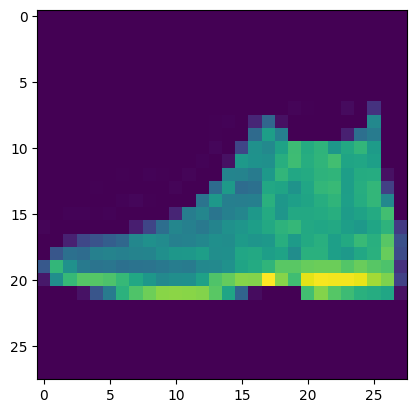

Trouser


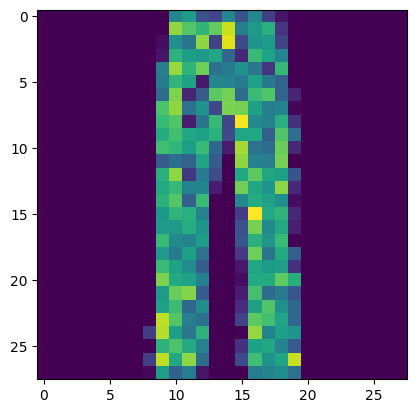

Bag


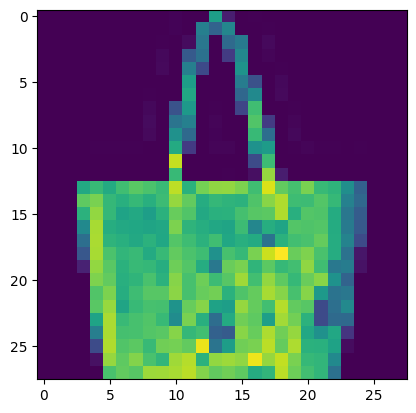

In [ ]:
for num, batch in enumerate(val_dataloader):
    images, class_nums = batch
    print(idx_to_label[int(class_nums[0])])
    plt.imshow(images[0].squeeze())
    plt.show()

    if num == 2:
        break

### Создание модели (общее для обоих подходов)



Создадим класс модели со следующей конфигурацией:

1. Conv(1->32, kernel=3, padding=1), BatchNorm, ReLU, MaxPool(2)
2. Conv(32->64, kernel=3, padding=1), BatchNorm, ReLU, MaxPool(2)
3. Flatten
4. Linear, ReLU
5. Linear

In [ ]:
class SimpleNet(torch.nn.Module):
    def __init__(self, dropout=0.4):
        super().__init__()

        self.conv1 = torch.nn.Sequential(
            torch.nn.Conv2d(1, 32, kernel_size=3, padding=1),
            torch.nn.BatchNorm2d(32),
            torch.nn.ReLU(),
            torch.nn.MaxPool2d(kernel_size=2),
        )

        self.conv2 = torch.nn.Sequential(
            torch.nn.Conv2d(32, 64, kernel_size=3, padding=1),
            torch.nn.BatchNorm2d(64),
            torch.nn.ReLU(),
            torch.nn.MaxPool2d(kernel_size=2),
        )

        self.classifier = torch.nn.Sequential(
            torch.nn.Flatten(),  # 64 * 7 * 7
            torch.nn.Linear(64 * 7 * 7, 128),
            torch.nn.ReLU(),
            torch.nn.Linear(128, 10),
        )

        self.loss_func = torch.nn.CrossEntropyLoss()
        self.targets = torch.Tensor()
        self.preds = torch.Tensor()

    def _forward(self, x):
        x = self.conv1(x)
        x = self.conv2(x)
        x = self.classifier(x)
        return x

    def forward(self, images, target=None):
        # images ~ (batch size, num channels, height, width)
        # target ~ (batch size)
        # output ~ (batch size, num classes)
        output = self._forward(images)

        # get accuracy score and save it to self.accuracy
        if target is not None:
            loss = self.loss_func(output, target)

            self.targets = torch.cat((self.targets, target.cpu()), 0)
            pred = torch.argmax(output, dim=-1)
            self.preds = torch.cat((self.preds, pred.cpu()), 0)
            self.accuracy = accuracy(
                self.preds.long(),
                self.targets.long(),
                task="multiclass",
                num_classes=10,
            )

        return loss if target is not None else output

    def get_accuracy(self, reset=False):
        if reset:
            self.targets = torch.Tensor()
            self.preds = torch.Tensor()
        return self.accuracy

### Гиперпараметры

In [ ]:
LossInfo = namedtuple(
    "LossInfo", ["full_train_losses", "train_epoch_losses", "eval_epoch_losses"]
)
EPOCHS = 3
LR = 0.001

### Тренировочные циклы (PyTorch)

Давайте объявим функции `train_epoch`, `validate`, `fit`.
Напомним, что структура выглядит в упрощенном виде так:
```
def train_epoch():
    for batch in train_loader:
        train_model_on_batch()
def validate():
    for batch in val_loader:
        validate_model_on_batch()
def fit():
    for epoch in range(1, num_epochs):
        train_epoch()
        validate()
```


Однако в коде выглядит довольно объемно...

In [ ]:
def train_epoch(
    model,
    data_loader,
    optimizer,
    return_losses=False,
    device="cuda:0",
):
    model = model.train()
    total_loss = 0
    num_batches = 0
    all_losses = []
    with tqdm(total=len(data_loader), file=sys.stdout) as prbar:
        for batch in data_loader:
            # move Batch to GPU
            batch = [x.to(device=device) for x in batch]
            loss = model(*batch)
            # update weights
            loss.backward()
            optimizer.step()
            optimizer.zero_grad()
            # update description for tqdm
            accuracy = model.get_accuracy()
            prbar.set_description(
                f"Loss: {round(loss.item(), 4)} "
                f"Accuracy: {round(accuracy.item() * 100, 4)}"
            )
            prbar.update(1)
            total_loss += loss.item()
            num_batches += 1
            all_losses.append(loss.detach().item())
    acc = model.get_accuracy(reset=True)
    metrics = {"loss": total_loss / num_batches, "accuracy": acc}
    if return_losses:
        return metrics, all_losses
    else:
        return metrics


def validate(model, data_loader, device="cuda:0"):
    model = model.eval()
    total_loss = 0
    num_batches = 0
    with tqdm(total=len(data_loader), file=sys.stdout) as prbar:
        for batch in data_loader:
            batch = [x.to(device=device) for x in batch]
            loss = model(*batch)
            accuracy = model.get_accuracy()
            prbar.set_description(
                f"Loss: {round(loss.item(), 4)} "
                f"Accuracy: {round(accuracy.item() * 100, 4)}"
            )
            prbar.update(1)
            total_loss += loss.item()
            num_batches += 1
    acc = model.get_accuracy(reset=True)
    metrics = {"loss": total_loss / num_batches, "accuracy": acc}
    return metrics

In [ ]:
def fit(
    model,
    epochs,
    train_data_loader,
    validation_data_loader,
    optimizer,
    scheduler=None,
    device="cuda:0",
):
    all_train_losses = []
    epoch_train_losses = []
    epoch_eval_losses = []
    for epoch in range(epochs):
        # construct iterators
        train_iterator = iter(train_data_loader)
        validation_iterator = iter(validation_data_loader)
        # train step
        print(f"Train Epoch: {epoch}")
        train_metrics, one_epoch_train_losses = train_epoch(
            model=model,
            data_loader=train_iterator,
            optimizer=optimizer,
            return_losses=True,
            device=device,
        )
        # save train losses
        all_train_losses.extend(one_epoch_train_losses)
        epoch_train_losses.append(train_metrics["loss"])
        # eval step
        print(f"Validation Epoch: {epoch}")
        with torch.no_grad():
            validation_metrics = validate(
                model=model, data_loader=validation_iterator, device=device
            )
        # save eval losses
        epoch_eval_losses.append(validation_metrics["loss"])
        # scheduler step
        if scheduler:
            scheduler.step()
    return LossInfo(all_train_losses, epoch_train_losses, epoch_eval_losses)

Давайте обучим модель

In [ ]:
model = SimpleNet().to(device)
_ = fit(
    model=model,
    epochs=EPOCHS,  # примерно минута на GPU в коллабе
    train_data_loader=train_dataloader,
    validation_data_loader=val_dataloader,
    optimizer=torch.optim.SGD(model.parameters(), lr=LR),
    device=device,
)

Train Epoch: 0


  0%|          | 0/469 [00:00<?, ?it/s]

Validation Epoch: 0


  0%|          | 0/79 [00:00<?, ?it/s]

Train Epoch: 1


...

  0%|          | 0/79 [00:00<?, ?it/s]

Train Epoch: 2


  0%|          | 0/469 [00:00<?, ?it/s]

Validation Epoch: 2


  0%|          | 0/79 [00:00<?, ?it/s]

### Тренировочные циклы (Lightning)

Здесь будет немного другая структура.

1) Создается один класс, отнаследованный от `LightningModule`. В нем задается конфигурация модели и описываются тренировчный и валидационный шаги.

2) Создается объект класса `Trainer` с параметрами (например, номер гпу, количество эпох, град. клиппинг и так далее) [дока](https://pytorch-lighting.readthedocs.io/en/stable/api/pytorch_lightning.trainer.trainer.Trainer.html?highlight=trainer#pytorch_lightning.trainer.trainer.Trainer)

3) Вызывается `trainer.fit(model, train_loader, val_loader)`.


```
class MyModule(pl.LightningModule):
    def init():
        init_model()
    def forward():
        forward_model()
    def training_step():
        make_1_training_step()
    def validation_step():
        make_1_validation_step()

trainer = pl.Trainer(gpus=1, max_epochs=10)
trainer.fit(model, train_loader, val_loader)
```
Поскольку у нас уже есть модель `SimpleNet`, то исправлять нам много не надо.

In [ ]:
# 1 step. Create a LightningModule


class SimpleModule(pl.LightningModule):
    def __init__(self, model, learning_rate):
        super().__init__()
        self.model = model
        self.learning_rate = learning_rate

    def forward(self, x):
        result = self.model(x)
        return result

    def configure_optimizers(self):
        optimizer = torch.optim.Adam(self.parameters(), lr=self.learning_rate)
        return optimizer

    def training_step(self, train_batch, batch_idx):
        images, target = train_batch
        loss = self.model(images, target)
        self.log(
            "train_loss", loss, prog_bar=True
        )  # сохраняет логи в папку, но можно несложно добавить wandb
        return loss

    def validation_step(self, val_batch, batch_idx):
        images, target = val_batch
        loss = self.model(images, target)
        self.log("val_loss", loss, prog_bar=True)

In [ ]:
# 2 step. Config a model


model = SimpleNet().to(device)
module = SimpleModule(model, learning_rate=LR)

# 3 step. Create Trainer and train
trainer = pl.Trainer(accelerator="gpu", max_epochs=EPOCHS)
trainer.fit(module, train_dataloader, val_dataloader)

INFO:pytorch_lightning.utilities.rank_zero:💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


┏━━━┳━━━━━━━┳━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name  ┃ Type      ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━╇━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ model │ SimpleNet │  421 K │ train │     0 │
└───┴───────┴───────────┴────────┴───────┴───────┘

Trainable params: 421 K                                                                                            
Non-trainable params: 0                                                                                            
Total params: 421 K                                                                                                
Total estimated model params size (MB): 1                                                                          
Modules in train mode: 17                                                                                          
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

Output()

INFO:pytorch_lightning.utilities.rank_zero:`Trainer.fit` stopped: `max_epochs=3` reached.


Обратите внимание **насколько** поведение `trainer.fit()` сильно похоже на написанную нами ранее функцию `fit()`


Заметьте также, что на Lightning мы:
1.   Не описывали тренировочный цикл ни по эпохам, ни по батчам
2.   Не рисковали забыть zero_grad, .backward()
3.   Не переносили ни модель, ни данные на GPU
4.   Получили всякие приколы типа auto_lr_find
5.   Сохранили возможность использования многих тонкостей **PyTorch** типа [schedulers](https://pytorch-lightning.readthedocs.io/en/stable/common/optimization.html), логирование через [wandb](https://docs.wandb.ai/guides/integrations/lightning) и так далее

In [ ]:
!wget https://download.microsoft.com/download/3/E/1/3E1C3F21-ECDB-4869-8368-6DEBA77B919F/kagglecatsanddogs_5340.zip
!unzip -qq kagglecatsanddogs_5340.zip
!rm -rf PetImages/Cat/666.jpg PetImages/Dog/11702.jpg readme\[1\].txt CDLA-Permissive-2.0.pdf

--2025-11-29 16:18:00--  https://download.microsoft.com/download/3/E/1/3E1C3F21-ECDB-4869-8368-6DEBA77B919F/kagglecatsanddogs_5340.zip
Resolving download.microsoft.com (download.microsoft.com)... 23.3.134.54, 2600:1402:b800:797::317f, 2600:1402:b800:791::317f
Connecting to download.microsoft.com (download.microsoft.com)|23.3.134.54|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 824887076 (787M) [application/octet-stream]
Saving to: ‘kagglecatsanddogs_5340.zip’

kagglecatsanddogs_5 100%[===================>] 786.67M  61.3MB/s    in 13s     

2025-11-29 16:18:14 (59.0 MB/s) - ‘kagglecatsanddogs_5340.zip’ saved [824887076/824887076]



In [ ]:
from torchvision.datasets import ImageFolder
from torchvision.transforms import Compose, Normalize, Resize, ToTensor

dataset = ImageFolder(
    "./PetImages",
    transform=Compose(
        [
            Resize((224, 224)),
            ToTensor(),
            Normalize((0.5, 0.5, 0.5), (1, 1, 1)),
        ]
    ),
)
train_set, val_set = torch.utils.data.random_split(
    dataset, [int(0.8 * len(dataset)), len(dataset) - int(0.8 * len(dataset))]
)

train_dataloader = torch.utils.data.DataLoader(train_set, batch_size=256, shuffle=True)
val_dataloader = torch.utils.data.DataLoader(val_set, batch_size=256, shuffle=False)

Посмотрим, как выглядят картинки.

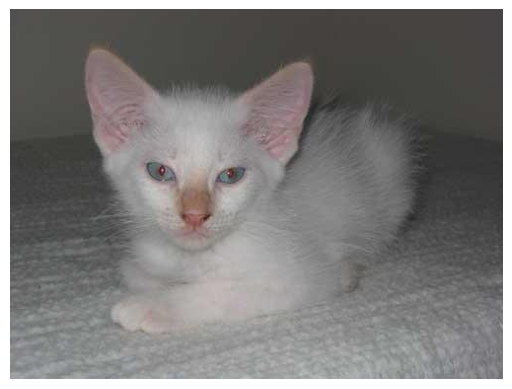

In [ ]:
import glob

file = np.random.choice(glob.glob("./PetImages/*/*.jpg"))
plt.axis("off")
plt.imshow(plt.imread(file));

## Fine-tuning

Кошки и собаки — это, конечно, хорошо, вот только обучение модели, которая будет хорошо работать на этом датасете может оказаться очень долгим...

Однако картинки, которые мы сегодня рассмотрим, оказываются очень похожими на картинки из огромного датасета ImageNet. Задача, которую мы сегодня рассмотрим, называется Transfer Learning. Знания мы действительно переносим — от сети, которая хорошо работает на одном датасете (ImageNet) к другим данным (к датасету Cats vs Dogs).

#### Загрузим уже обученную сеть

В библиотеке `torchvision` имплементировано не только большое множество моделей (всевозможные ResNet'ы, Inception, VGG, AlexNet, DenseNet, ResNext, WideResNet, MobileNet...), но и загружены чекпоинты обучения этих моделей на ImageNet. Однако для датасета Cats vs Dogs такая штука является роскошью...

In [ ]:
!pip install pytorch_lightning torchmetrics torchvision

In [ ]:
import pytorch_lightning as pl
from torchmetrics.functional import accuracy
from torchvision.models import resnet18

In [ ]:
model = resnet18(pretrained=True)
model

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 73.8MB/s]


ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

В задаче transfer learning'a мы заменяем последний слой нейросети на линейный с двумя выходами, а веса остальных слоёв "замораживаем".

In [ ]:
class CatsVSDogsResnet(pl.LightningModule):
    def __init__(self, pretrained: bool = False) -> None:
        super().__init__()
        self.pretrained = pretrained

        if pretrained:
            # <YOUR CODE HERE>
            self.model = resnet18(pretrained=True)
            self.model.fc = nn.Identity()
            self.classifier = nn.Linear(512, 2)
            self.optimizer = torch.optim.Adam(self.classifier.parameters())
        else:
            # <YOUR CODE HERE>
            self.model = resnet18(pretrained=False)
            self.model.fc = nn.Linear(self.model.fc.in_features, 2)
            self.optimizer = torch.optim.Adam(self.model.parameters())

        self.loss = nn.CrossEntropyLoss()

    def forward(self, x) -> torch.Tensor:
        if self.pretrained:
            # <YOUR CODE HERE>
            with torch.no_grad():
                features = self.model(x)
            preds = self.classifier(features)
        else:
            # <YOUR CODE HERE>
            preds = self.model(x)
        return preds

    def configure_optimizers(self):
        return self.optimizer

    def training_step(self, train_batch, batch_idx) -> torch.Tensor:
        images, target = train_batch
        preds = self.forward(images)
        loss = self.loss(preds, target)
        self.log("train_loss", loss, prog_bar=True)
        return loss

    def validation_step(self, val_batch, batch_idx) -> None:
        images, target = val_batch
        preds = self.forward(images)
        loss = self.loss(preds, target)
        acc = accuracy(torch.argmax(preds, dim=-1).long(), target.long(), task="binary")
        self.log("val_loss", loss, prog_bar=True)
        self.log("accuracy", acc, prog_bar=True)

Запустим transfer learning!

In [ ]:
cats_vs_dogs_pretrained = CatsVSDogsResnet(pretrained=True)

trainer = pl.Trainer(accelerator="auto", max_epochs=1)
trainer.fit(cats_vs_dogs_pretrained, train_dataloader, val_dataloader)

INFO:pytorch_lightning.utilities.rank_zero:💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


┏━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name       ┃ Type             ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ model      │ ResNet           │ 11.2 M │ train │     0 │
│ 1 │ classifier │ Linear           │  1.0 K │ train │     0 │
│ 2 │ loss       │ CrossEntropyLoss │      0 │ train │     0 │
└───┴────────────┴──────────────────┴────────┴───────┴───────┘

Trainable params: 11.2 M                                                                                           
Non-trainable params: 0                                                                                            
Total params: 11.2 M                                                                                               
Total estimated model params size (MB): 44                                                                         
Modules in train mode: 70                                                                                          
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

Output()

INFO:pytorch_lightning.utilities.rank_zero:`Trainer.fit` stopped: `max_epochs=1` reached.


Уже после одной эпохи получается приемлемое качество! Давайте проверим, что получится, если учить ResNet с нуля.

In [ ]:
np.random.seed(42)

In [ ]:
np.random.random()

0.3745401188473625

In [ ]:
cats_vs_dogs = CatsVSDogsResnet(pretrained=False)

trainer = pl.Trainer(accelerator="auto", max_epochs=1)
trainer.fit(cats_vs_dogs, train_dataloader, val_dataloader)

INFO:pytorch_lightning.utilities.rank_zero:💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


┏━━━┳━━━━━━━┳━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name  ┃ Type             ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━╇━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ model │ ResNet           │ 11.2 M │ train │     0 │
│ 1 │ loss  │ CrossEntropyLoss │      0 │ train │     0 │
└───┴───────┴──────────────────┴────────┴───────┴───────┘

Trainable params: 11.2 M                                                                                           
Non-trainable params: 0                                                                                            
Total params: 11.2 M                                                                                               
Total estimated model params size (MB): 44                                                                         
Modules in train mode: 69                                                                                          
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

Output()

INFO:pytorch_lightning.utilities.rank_zero:`Trainer.fit` stopped: `max_epochs=1` reached.


Как мы видим, на transfer learning'e нейросеть сходится очень быстро. Значительно быстрее, чем инициализированная с нуля. Можно с уверенностью говорить, что transfer learning — очень полезная техника.

### Изучмм adversarial attacks на примере Fast Gradient Sign Attack

Такая вещь, как атаки на нейросеть крайне важны для учёта при разработке. Существует много методов как их генерации, так и защиты от них. Мы рассмотрим сегодня базовые концепты, чтобы дать понимание происходящего.

Можем назвать adversarial атакой генерацию такого примера, который не отличим глазом от настоящего, но нейросеть будет ОЧЕНЬ уверена в том, что этот пример из другого класса. Сейчас мы попробуем сгенерировать такую собачку, что нейросеть будет уверена, что это котик.

Сегодня мы рассмотрим пример Fast Gradient Sign Attack (FGSM, почему там буква M в конце — чёрт его знает...). Идея очень простая. Оказывается, что если мы через обученную нейросеть посчитаем градиент по исходной картинке, посчитаем его знак и прибавим, умножив на маленькое число, модель подумает, что это картинка другого класса.

<img src="https://pytorch.org/tutorials/_images/fgsm_panda_image.png">

In [ ]:
def fgsm_attack(
    original_image: torch.Tensor, epsilon: float, data_grad: torch.Tensor
) -> torch.Tensor:
    # <YOUR CODE HERE>
    perturbated_image = original_image + epsilon * torch.sign(data_grad)
    return perturbated_image

In [ ]:
model = nn.Sequential(cats_vs_dogs_pretrained.model, cats_vs_dogs_pretrained.classifier)
model.eval()
for param in model.parameters():
    param.requires_grad = True

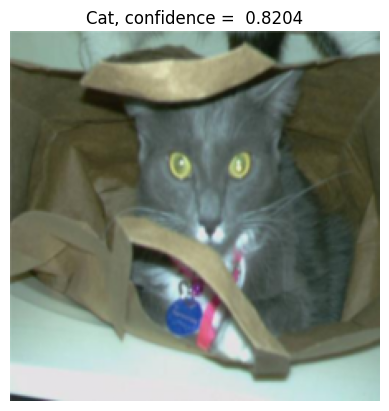

In [ ]:
while True:
    # ищем кошку
    idx = np.random.randint(0, len(train_set))
    if train_set[idx][1] != 0:
        continue
    cat_image = train_set[idx][0]
    break

# Разрешим вычисление градиента по картинке
cat_image.requires_grad = True

pred = model(cat_image[None])
predicted_label = pred.argmax(1).item()
confidence = pred.softmax(1)[0][predicted_label]
if predicted_label == 1:
    plt.title("Dog, confidence = %0.4f" % confidence.item())
else:
    plt.title("Cat, confidence =  %0.4f" % confidence.item())
plt.axis("off")
plt.imshow(cat_image.cpu().detach().numpy().transpose((1, 2, 0)) + 0.5);

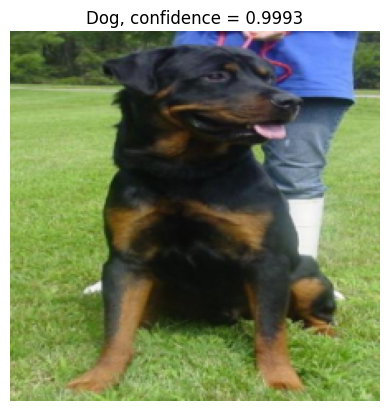

In [ ]:
while True:
    # ищем кошку
    idx = np.random.randint(0, len(train_set))
    if train_set[idx][1] == 0:
        continue
    dog_image = train_set[idx][0]
    break
pred = model(dog_image[None])
predicted_label = pred.argmax(1).item()
confidence = pred.softmax(1)[0][predicted_label]
if predicted_label == 1:
    plt.title("Dog, confidence = %0.4f" % confidence.item())
else:
    plt.title("Cat, confidence =  %0.4f" % confidence.item())
plt.axis("off")
plt.imshow(dog_image.cpu().detach().numpy().transpose((1, 2, 0)) + 0.5);

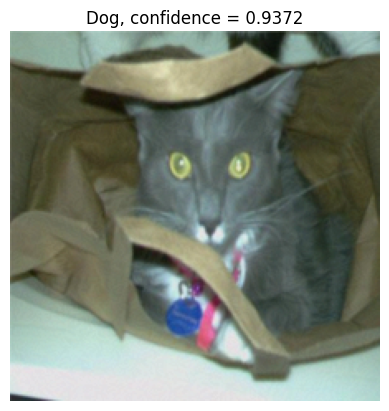

In [ ]:
loss = nn.CrossEntropyLoss()(pred, torch.tensor(0).reshape((1,)))
loss.backward()

eps = 0.007

cat_image_perturbated = fgsm_attack(cat_image, eps, cat_image.grad)
pred = model(cat_image_perturbated[None])
predicted_label = pred.argmax(1).item()
confidence = pred.softmax(1)[0][predicted_label]

plt.axis("off")
if predicted_label == 1:
    plt.title("Dog, confidence = %0.4f" % confidence.item())
else:
    plt.title("Cat, confidence =  %0.4f" % confidence.item())
plt.imshow(cat_image_perturbated.cpu().detach().numpy().transpose((1, 2, 0)) + 0.5);

In [ ]:
dogcat = 0.9 * cat_image + 0.1 * dog_image
model(dogcat.unsqueeze(0))

tensor([[ 1.3083, -0.3554]], grad_fn=<AddmmBackward0>)